# Notebook 13 — Fine-Tuning del Clasificador de Género
Entrenamiento de DistilBERT multilingüe para clasificar Rock / Hip-Hop / Metal.

---
## 1. Importaciones

Se importan las funciones del módulo `finetuning_utils`, centralizando la lógica del entrenamiento y evaluación.

In [1]:
import sys, os, time, json
import pandas as pd

sys.path.append(os.path.abspath('../../../..'))

from src.Proyecto_3.finetuning_utils import (
    preparar_dataset,
    evaluar_zero_shot,
    entrenar_clasificador,
    evaluar_y_guardar,
    ejecutar_pruebas_inferencia,
    GENEROS_TARGET
)

print('✓ Importaciones completadas')

✓ Importaciones completadas


---
## 2. Carga y preparación del corpus

Cargamos el dataset procesado y realizamos la división en conjuntos de entrenamiento, validación y prueba (70/15/15).

In [2]:
df = pd.read_csv('../data/processed/canciones_limpias.csv')

print(f'\nEstadísticas del corpus para Fine-Tuning:')
ds_train, ds_val, ds_test, le, df_target = preparar_dataset(
    df, text_col='Lyrics', label_col='Genre'
)

print(f'\n✓ Clases objetivo detectadas: {le.classes_.tolist()}')


Estadísticas del corpus para Fine-Tuning:


D:\kenda\Downloads\Analisis-Morfosintactico-de-Letras-Musicales-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✓ Clases objetivo detectadas: ['Hip-Hop', 'Metal', 'Rock']


---
## 3. Baseline Zero-Shot (Sin Fine-Tuning)

Evaluación del modelo base preentrenado para cuantificar la ganancia real obtenida tras el entrenamiento especializado.

In [3]:
acc_zs, f1_zs = evaluar_zero_shot(df_target, sample_size=100)


⚙ Calculando Baseline Zero-Shot con 100 muestras aleatorias...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6620.01it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive

  ✓ Zero-Shot completado en 16.4s
  → Accuracy Zero-Shot: 0.3300 | F1 Macro: 0.2856


---
## 4. Entrenamiento del Clasificador

Fine-tuning de DistilBERT durante 3 épocas. Se busca optimizar el F1-Macro para manejar el balance entre géneros.

Si no sirver usar (reiniciar kernel cuando termine)

In [4]:
#!pip install "accelerate>=1.1.0"

In [5]:
trainer, model = entrenar_clasificador(
    ds_train, 
    ds_val, 
    num_labels=len(le.classes_), 
    num_epochs=3
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5525.80it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.683223,0.698003,0.713287,0.709883
2,0.492296,0.724456,0.722278,0.722274
3,0.227922,0.945665,0.727273,0.728445


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.59s/it]

✓ Modelo guardado en D:\kenda\Downloads\Analisis-Morfosintactico-de-Letras-Musicales-main (3)\Analisis-Morfosintactico-de-Letras-Musicales-main\models\clasificador_genero


---
## 5. Evaluación de Ganancia y Métricas

Se reportan los resultados sobre el conjunto de test y se genera la matriz de confusión definitiva.


COMPARACIÓN FINAL
Zero-Shot  — Accuracy: 0.3300 | F1: 0.2856
Fine-Tuned — Accuracy: 0.7455 | F1: 0.7470
Ganancia   — Accuracy: +0.4155 | F1: +0.4614


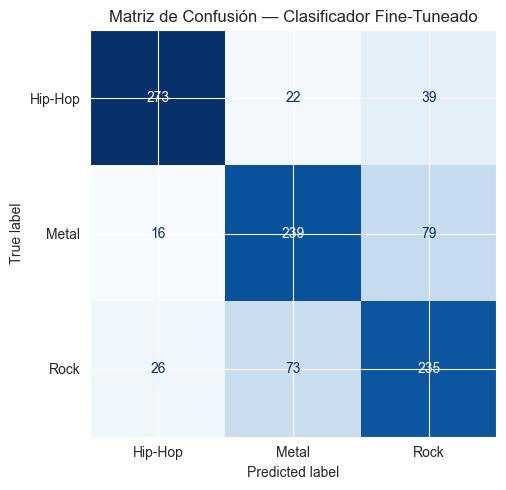


✓ Métricas y gráfico guardados en la carpeta 'resultados'.


In [6]:
metricas = evaluar_y_guardar(trainer, ds_test, le, acc_zs=acc_zs, f1_zs=f1_zs)

---
## 6. Pruebas de Inferencia

Validación con frases de prueba para asegurar que la personalidad del chatbot esté alineada con las predicciones del modelo.

In [7]:
ejemplos_test = [
    'I rage against the machine, break the chains of society',
    'Check the rhyme, street life is the urban grind',
    'Death and mortality consume my metal soul'
]

ejecutar_pruebas_inferencia(ejemplos_test)


 Pruebas de Inferencia Rápidas:


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4745.72it/s]

  Texto: "I rage against the machine, break the chains of society..." 
  → Predicción: Rock

  Texto: "Check the rhyme, street life is the urban grind..." 
  → Predicción: Rock

  Texto: "Death and mortality consume my metal soul..." 
  → Predicción: Rock

